# Example Sheet 2 — Computational solutions

## Question 3: Quorum sensing in Python

Consider
$$
\dot y=\alpha\frac{x^2}{K^2+x^2}-\gamma y,\qquad
\dot x=k_xy+u-\delta x,
$$
with
$$
\alpha=1,\quad K=0.5,\quad \gamma=1,\quad
k_x=1,\quad \delta=1,\quad u=0.02.
$$

### (a) Biological interpretation

Intracellular AHL activates the Lux promoter through LuxR binding and
dimerisation. This increases LuxI expression, while LuxI produces more
AHL. Thus the positive-feedback loop is

$$
\mathrm{AHL}\rightarrow\mathrm{promoter\ activation}
\rightarrow\mathrm{LuxI}\rightarrow\mathrm{AHL}.
$$

The parameter $u$ represents influx of extracellular AHL.

### (b) Right-hand side

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.integrate import solve_ivp

alpha = 1.0
K = 0.5
gamma = 1.0
kx = 1.0
delta = 1.0
u = 0.02

def f(t, z):
    y, x = z
    dy = alpha*x**2/(K**2 + x**2) - gamma*y
    dx = kx*y + u - delta*x
    return np.array([dy, dx])

### (c) Numerical equilibria

In [2]:
def f_root(z):
    return f(0.0, z)

# Use a grid of initial guesses to make missing a root unlikely.
grid = np.linspace(0.0, 1.0, 7)
guesses = [np.array([y0, x0]) for y0 in grid for x0 in grid]

equilibria = []

for guess in guesses:
    sol = root(f_root, guess)
    if not sol.success:
        continue

    zstar = sol.x

    if np.all(zstar >= -1e-8) and np.all(zstar <= 1.0 + 1e-8):
        if not any(np.linalg.norm(zstar-z) < 1e-6 for z in equilibria):
            equilibria.append(zstar)

equilibria = sorted(equilibria, key=lambda z: z[1])

for i, zstar in enumerate(equilibria, start=1):
    print(f"z*_{i} = [{zstar[0]:.6f}, {zstar[1]:.6f}]")

z*_1 = [0.001918, 0.021918]
z*_2 = [0.334411, 0.354411]
z*_3 = [0.623671, 0.643671]


The equilibria are approximately
$$
z^\star_1=
\begin{bmatrix}0.00192\\0.02192\end{bmatrix},\qquad
z^\star_2=
\begin{bmatrix}0.33441\\0.35441\end{bmatrix},\qquad
z^\star_3=
\begin{bmatrix}0.62367\\0.64367\end{bmatrix}.
$$

### (d) Perturbation simulations

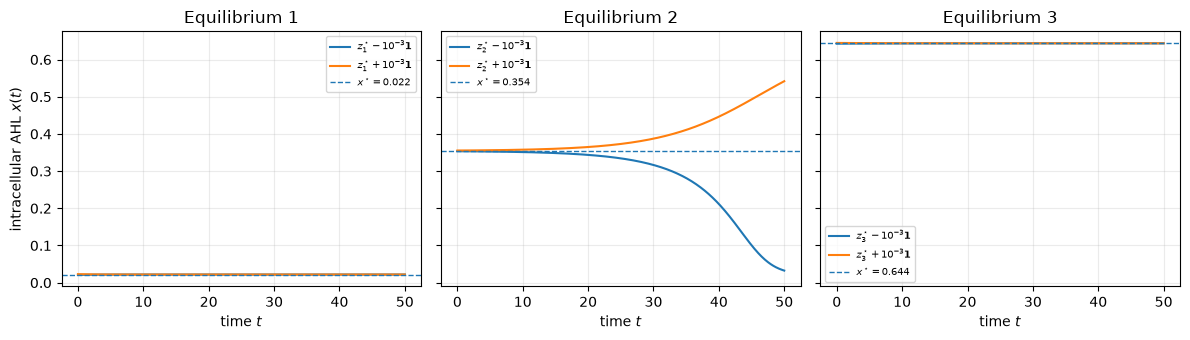

In [ ]:
eps = 1e-3

fig, axes = plt.subplots(1, len(equilibria), figsize=(12, 3.5), sharey=True)
if len(equilibria) == 1:
    axes = [axes]

for i, (ax, zstar) in enumerate(zip(axes, equilibria), start=1):
    for sign in [-1, 1]:
        z0 = zstar + sign*eps*np.ones(2)

        sol = solve_ivp(
            f, (0, 100), z0,
            rtol=1e-9,
            atol=1e-11,
            max_step=0.1,
        )

        ax.plot(
            sol.t, sol.y[1],
            label=fr"$z^\star_{i}{'+' if sign > 0 else '-'}10^{{-3}}\mathbf{{1}}$"
        )

    ax.axhline(zstar[1], linestyle="--", linewidth=1, label=fr"$x^\star={zstar[1]:.3f}$")
    ax.set_title(fr"Equilibrium {i}")
    ax.set_xlabel("time $t$")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7)

axes[0].set_ylabel("intracellular AHL $x(t)$")
plt.tight_layout()
plt.show()

### (e) Stability and switch-like behaviour

Perturbations around $z^\star_1$ and $z^\star_3$ return towards the
respective equilibria, whereas perturbations around $z^\star_2$ move
away. Therefore,
$$
z^\star_1\ \text{stable},\qquad
z^\star_2\ \text{unstable},\qquad
z^\star_3\ \text{stable}.
$$

The two stable equilibria correspond to low- and high-AHL states. The
unstable intermediate equilibrium acts as a threshold separating the
two regimes, giving the circuit switch-like behaviour.

---

## Question 4 (optional): Stability of a system by linearisation

### (a) Jacobian

Differentiating the two components gives
$$
J(y,x)=
\begin{bmatrix}
-\gamma & \dfrac{2\alpha K^2x}{(K^2+x^2)^2}\\[1em]
k_x & -\delta
\end{bmatrix}.
$$

### (b)–(c) Jacobians and eigenvalues at the equilibria

In [4]:
def jacobian(z):
    y, x = z
    dhdx = 2*alpha*K**2*x / (K**2 + x**2)**2
    return np.array([
        [-gamma, dhdx],
        [kx, -delta],
    ])

eigvals_all = []

for i, zstar in enumerate(equilibria, start=1):
    J = jacobian(zstar)
    eig = np.linalg.eigvals(J)
    eigvals_all.append(eig)

    print(f"Equilibrium {i}:")
    print("z* =", zstar)
    print("J =")
    print(J)
    print("eigenvalues =", eig)
    print()

Equilibrium 1:
z* = [0.00191789 0.02191789]
J =
[[-1.          0.17467119]
 [ 1.         -1.        ]]
eigenvalues = [-0.58206318+0.j -1.41793682+0.j]

Equilibrium 2:
z* = [0.33441108 0.35441108]
J =
[[-1.          1.25605728]
 [ 1.         -1.        ]]
eigenvalues = [ 0.12073961+0.j -2.12073961+0.j]

Equilibrium 3:
z* = [0.62367103 0.64367103]
J =
[[-1.          0.72927153]
 [ 1.         -1.        ]]
eigenvalues = [-0.14602604+0.j -1.85397396+0.j]



Numerically, the Jacobians are approximately
$$
J(z^\star_1)=
\begin{bmatrix}-1&0.1747\\1&-1\end{bmatrix},\qquad
J(z^\star_2)=
\begin{bmatrix}-1&1.2561\\1&-1\end{bmatrix},\qquad
J(z^\star_3)=
\begin{bmatrix}-1&0.7293\\1&-1\end{bmatrix}.
$$

The corresponding eigenvalues are approximately
$$
(-0.5821,-1.4179),\qquad
(0.1207,-2.1207),\qquad
(-0.1460,-1.8540).
$$

### (d) Stability

Both eigenvalues of $J(z^\star_1)$ and $J(z^\star_3)$ are negative, so
these equilibria are locally asymptotically stable. Since
$J(z^\star_2)$ has one positive eigenvalue, $z^\star_2$ is unstable.

This agrees with the simulations in Question 3.